# Lab08 - 1D Energy Balance Model - Lab bench

Load packages. If you are working in the course Binder instance, climlab is pre-installed.

In [ ]:
%%capture
%pip install climlab

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import climlab
from climlab import constants as const
from climlab.radiation.aplusbt import AplusBT_CO2
import pandas as pd

try:
    plt.style.use('bmh')
except:
    print('default plotting style')

#  Reference parameters — used throughout the lab
param = {
    'D':  0.55,   # diffusivity W/m²/°C
    'A':  210.,   # OLR intercept W/m²
    'B':  2.,     # OLR slope W/m²/°C
    'a0': 0.3,    # ice-free albedo (equator)
    'a2': 0.078,  # albedo gradient (P2 coefficient)
    'ai': 0.62,   # ice-covered albedo
    'Tf': -10.,   # ice threshold °C
}

In [ ]:
def ebm_to_dfs(e):
    """
    Extract the plotted EBM diagnostics into dataframes.

    Returns
    -------
    state_df : pd.DataFrame
        Fields defined on e.lat
    transport_df : pd.DataFrame
        Fields defined on e.lat_bounds
    """
    state_df = pd.DataFrame({
        "lat": np.asarray(np.squeeze(e.lat)),
        "Ts": np.asarray(np.squeeze(e.Ts)),
        "ASR": np.asarray(np.squeeze(e.ASR)),
        "OLR": np.asarray(np.squeeze(e.OLR)),
        "neg_OLR": -np.asarray(np.squeeze(e.OLR)),
        "net_radiation": np.asarray(np.squeeze(e.net_radiation)),
        "heat_transport_convergence": np.asarray(np.squeeze(e.heat_transport_convergence)),
        "total_budget": (
            np.asarray(np.squeeze(e.net_radiation))
            + np.asarray(np.squeeze(e.heat_transport_convergence))
        ),
    })

    transport_df = pd.DataFrame({
        "lat_bounds": np.asarray(np.squeeze(e.lat_bounds)),
        "heat_transport": np.asarray(np.squeeze(e.heat_transport)),
    })

    icelat = np.asarray(e.icelat).copy() if hasattr(e, "icelat") else None

    return state_df, transport_df, icelat

# Three-panel diagnostic: temperature / energy budget / heat transport

def ebm_plot(e=None, dfs = None, Tf=None, icelat=None,
                      fig=None, axs=None, title=None, legend=True):
    templimits = (-65, 35)
    radlimits  = (-340, 340)
    htlimits   = (-7, 7)
    latlimits  = (-90, 90)
    lat_ticks  = np.arange(-90, 90, 30)

    if fig is None:
        fig = plt.figure(figsize=(8, 10))
        axs = fig.subplots(3, 1)
    elif axs is None:
        axs = [fig.add_subplot(3, 1, i + 1) for i in range(3)]

    if e is not None:
        state_df, transport_df, icelat = ebm_to_dfs(e)
    if dfs is not None:
        state_df, transport_df, icelat = dfs

    ax1, ax2, ax3 = axs

    ax1.plot(state_df["lat"], state_df["Ts"])
    if Tf is not None:
        ax1.axhline(Tf, color="gray", ls=":", lw=1, label=f"$T_f$ = {Tf}°C")
        ax1.legend(fontsize=8, loc="upper right")
    ax1.set_ylim(templimits)
    ax1.set_ylabel("Temperature (°C)")

    ax2.plot(state_df["lat"], state_df["ASR"], "k--", label="SW absorbed")
    ax2.plot(state_df["lat"], state_df["neg_OLR"], "r--", label="−OLR")
    ax2.plot(state_df["lat"], state_df["net_radiation"], "c-", label="net rad")
    ax2.plot(
        state_df["lat"],
        state_df["heat_transport_convergence"],
        "g--",
        label="dyn",
    )
    ax2.plot(state_df["lat"], state_df["total_budget"], "b-", label="total")
    ax2.set_ylim(radlimits)
    ax2.set_ylabel("Energy budget (W m⁻²)")
    if legend:
        ax2.legend(bbox_to_anchor=(1.12, 0.5), fontsize=8)

    ax3.plot(transport_df["lat_bounds"], transport_df["heat_transport"])
    if icelat is not None:
        for il in np.atleast_1d(icelat):
            if not np.isnan(il):
                ax3.axvline(
                    il, color="steelblue", alpha=0.7, ls=":", lw=1.5,
                    label=f"ice edge {il:.1f}°"
                )
        ax3.legend(fontsize=8, loc="lower center")
    ax3.set_ylim(htlimits)
    ax3.set_ylabel("Heat transport (PW)")

    for ax in (ax1, ax2, ax3):
        ax.set_xlabel("Latitude φ")
        ax.set_xlim(latlimits)
        ax.set_xticks(lat_ticks)
        ax.grid(True, alpha=0.4)

    if title:
        ax1.set_title(title, fontweight="bold")#, y=1.01)
    fig.tight_layout()

    return fig, axs

# ── CO₂ setter ────────────────────────────────────────────────────────────────
def set_co2(model, co2):
    """Replace the LW subprocess with a CO₂-aware version."""
    LW = AplusBT_CO2(CO2=float(co2), state=model.state,
                     timestep=model.timestep)
    model.add_subprocess('LW', LW)

------------------------------------------------------------------------

------------------------------------------------------------------------


## Part 1: From 0D to 1D


### Review: the zero-dimensional model

In Lab 4 you built a zero-dimensional energy balance model governed by

$$
C_s \frac{dT}{dt} = \underbrace{\left(1 - \alpha(T)\right)\frac{S_0}{4}}_{\text{absorbed solar}} - \underbrace{\sigma T_e^4}_{\text{OLR}} \equiv G(T)
$$

The system had one state variable ($T$), one control parameter ($S_0$), and an albedo function $\alpha(T)$ that depended nonlinearly on temperature. That nonlinearity — ice forming or melting globally as temperature crossed a threshold — was enough to produce multiple equilibria, a stability diagram, and a bifurcation diagram with hysteresis.

The bifurcation diagram below is a quick reminder. Run the cell to regenerate it from the Lab 4 model — you’ll use it as a reference throughout this lab.


In [ ]:
# ── Lab 4 functions (self-contained) ─────────────────────────────────────────
from scipy import constants as scipy_const

_sigma    = scipy_const.sigma
_alpha_i  = param['ai']
_alpha_0  = param['a0']
_T1, _T2  = 260., 290.   # Lab 4 albedo transition limits (K)

def lab4_albedo(T):
    T = float(T)
    if T < _T1:
        return _alpha_i
    elif _T1 <= T <= _T2:
        r = (T - _T2)**2 / (_T2 - _T1)**2
        return _alpha_0 + (_alpha_i - _alpha_0) * r
    else:
        return _alpha_0

def lab4_OLR(T, pRad=670., ps=1000.):
    Te = (pRad / ps)**(2./7.) * T
    return _sigma * Te**4.

def lab4_G(T, S0, pRad=670.):
    return (S0 / 4.) * (1. - lab4_albedo(T)) - lab4_OLR(T, pRad)

# ── Bifurcation diagram: equilibrium T vs S0 ─────────────────────────────────
# Balance function approach from Lab 4
Tvec  = np.linspace(200., 340., 1000)
pRad  = 670.   # present-day greenhouse strength

# L_eq(T) = 4 * OLR(T) / (1 - alpha(T))
L_eq = np.array([4. * lab4_OLR(T, pRad) / (1. - lab4_albedo(T)) for T in Tvec])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(L_eq, Tvec - 273.15, 'steelblue', lw=2, label='balance function')
ax.axvline(1365.2, color='k', ls='--', lw=1, label='present-day $S_0$')
ax.set_xlabel('Solar constant $S_0$ (W m⁻²)', fontsize=12)
ax.set_ylabel('Surface temperature (°C)', fontsize=12)
ax.set_title('Lab 4 bifurcation diagram (0D model, $p_{rad}$ = 670 mb)', fontsize=12)
ax.set_xlim(900, 2200)
ax.set_ylim(-80, 80)
ax.legend()
ax.grid(True, alpha=0.4)
fig.tight_layout()

**Q:** Orient yourself on this diagram. Which segments are stable and which unstable? Mark the two bifurcation points. Where would you place present-day Earth? Neoproterozoic Earth (~7% lower $S_0$)?

------------------------------------------------------------------------


### The 1D EBM

Now we relax the assumption that the climate is a single point. We resolve temperature as a function of latitude $\phi$, governed by

$$
C \frac{\partial T}{\partial t} = \underbrace{(1-\alpha(\phi,T))\,Q(\phi)}_{\text{absorbed solar}} - \underbrace{(A + B\,T)}_{\text{OLR}} + \underbrace{\frac{D}{\cos\phi}\frac{\partial}{\partial\phi}\!\left(\cos\phi\,\frac{\partial T}{\partial\phi}\right)}_{\text{meridional heat transport}}
$$

Three things are new compared to the 0D model:

**Insolation varies with latitude.** $Q(\phi)$ is the annual-mean solar radiation reaching each latitude — largest at the equator, smallest at the poles.

**OLR is linearized.** Rather than $\sigma T_e^4$, we use $A + B\,T$, a linear approximation around a reference state. The parameter $A$ captures the greenhouse effect: lower $A$ means more infrared is trapped, warming the surface. This is how we will represent $\text{CO}_2$ forcing later in the lab.

**The atmosphere transports energy.** The diffusion term moves heat poleward from where there is surplus (tropics) to where there is deficit (poles). The strength of this transport is set by the diffusivity $D$.


### The ice line

The most important new element is the **ice line**: a latitude that moves as temperature changes. Wherever $T(\phi) \leq T_f = -10\,^\circ$C, the surface is ice-covered with albedo $a_i = 0.62$. Elsewhere the albedo follows a smooth latitudinal profile:

$$
\alpha(\phi, T) = \begin{cases}
a_i & T(\phi) \leq T_f \\
a_0 + a_2\,P_2(\sin\phi) & T(\phi) > T_f
\end{cases}
$$

Compare this to the Lab 4 albedo function $\alpha(T)$, which depended on global mean temperature. Here albedo depends on *local* temperature at each latitude. A small change in $S_0$ that cools the high latitudes below $T_f$ will cause ice to form there — changing the local albedo — without necessarily affecting the tropics at all. The feedback is now spatially selective, not global.

Build the EBM with interactive ice line, integrate to equilibrium, and check energy balance.


In [ ]:
model1 = climlab.EBM_annual(
    name='EBM — present-day',
    num_lat=180,
    **param
)
model1.integrate_years(5, verbose=False)
model1.integrate_years(5, verbose=False)
print('Net radiation (should be ~0):', climlab.global_mean(model1.net_radiation))
print('Ice edge latitude:', model1.icelat)
print('Global mean Ts:   ', climlab.global_mean(model1.Ts))

In [ ]:
ebm_plot(model1, title='1D EBM — present-day parameters')

**Q:** Work through each panel. Top: where does temperature cross $T_f$? Middle: describe the energy budget at the equator, ±35°, and ±70°. Bottom: what does it mean that “dyn” is negative equatorward of ±35° and positive poleward? Why does heat transport drop at the ice edge?

------------------------------------------------------------------------

------------------------------------------------------------------------


## Part 2: Polar Amplification and S₀


### Forcing the EBM with S₀

The simplest forcing we can apply to this model is a change in $S_0$ — the same knob we turned in Lab 4. But now temperature is resolved by latitude, so we can ask not just *how much* the climate changes but *where*.

Clone the present-day model, reduce $S_0$ by 50 W m⁻², integrate to equilibrium, and compare.


In [ ]:
model_S0low = climlab.process_like(model1)
model_S0low.name = 'EBM — reduced S0'
model_S0low.subprocess.insolation.S0 = 1315.   # 50 W/m² reduction
model_S0low.integrate_years(10, verbose=False)

print('Present-day ice edge:', model1.icelat)
print('Reduced S0 ice edge: ', model_S0low.icelat)
print('Global mean ΔTs:     ', float(climlab.global_mean(model_S0low.Ts - model1.Ts)))

In [ ]:
dT_S0 = model_S0low.Ts - model1.Ts

fig, a1 = plt.subplots(figsize=(8, 5))
a1.plot(model1.lat,      model1.Ts,      label=f'$S_0$ = 1365 W m⁻²', color='tab:red')
a1.plot(model_S0low.lat, model_S0low.Ts, label=f'$S_0$ = 1315 W m⁻²', color='tab:blue')
a1.axhline(param['Tf'], color='gray', ls=':', lw=1, label='$T_f$')
a1.set_ylabel('Temperature (°C)')
a1.set_xlabel('Latitude (°)')
a1.set_ylim(-65, 35)
a1.legend()
a1.grid(True, alpha=0.4)

a2 = a1.twinx()
a2.plot(model1.lat, dT_S0, color='k', lw=1.5, ls='--',
        label=r'$\Delta T$ (reduced $S_0$ − present)')
a2.axhline(float(climlab.global_mean(dT_S0)), color='k', lw=1, ls=':',
           label='global mean $\Delta T$')
a2.set_ylabel(r'$\Delta T$ (°C)')
a2.set_ylim(-12, 2)

lines1, labels1 = a1.get_legend_handles_labels()
lines2, labels2 = a2.get_legend_handles_labels()
a1.legend(lines1 + lines2, labels1 + labels2, loc='lower center',
          fontsize=8, frameon=True)
a1.set_title('Temperature response to $S_0$ reduction')
fig.tight_layout()

**Q:** Where is cooling largest? What moved in the model to cause extra high-latitude cooling? The 0D model predicts approximately $\Delta T_{0D} \approx -6\,^\circ$C for this $\Delta S_0$. How does the 1D result compare, and why might they differ?


### Temperature at specific latitudes

The global mean is one way to summarize the response, but it hides the spatial structure. Extract temperature at 20°N, 45°N, and 65°N for both model states, and write the results to a small CSV.

Extract temperature at three latitudes for both model states.


In [ ]:
def get_lat_idx(model, lat_deg):
    """Return the index of the grid point closest to lat_deg."""
    return int(np.argmin(np.abs(model.lat - lat_deg)))

target_lats = np.arange(-75, 76, 5)#[20., 45., 65.]

lat_data = []
for lat in target_lats:
    idx = get_lat_idx(model1, lat)
    lat_data.append({
        'lat': lat,
        'Ts_present': float(np.squeeze(model1.Ts[idx])),
        'Ts_S0low':   float(np.squeeze(model_S0low.Ts[idx])),
        'dT':         float(np.squeeze(model_S0low.Ts[idx] - model1.Ts[idx])),
    })

df_lats = pd.DataFrame(lat_data)
print(df_lats.to_string(index=False))
df_lats.to_csv('lab08_lat_temps_S0.csv', index=False)
print('\nSaved to lab08_lat_temps_S0.csv')

**Q:** At which latitude is the response largest? Is this consistent with where the ice line moved? What does the global mean miss about this event?

------------------------------------------------------------------------

------------------------------------------------------------------------


## Part 3: Snowball Earth


### Walking the ice line to the equator

In Lab 4 you saw the Snowball bifurcation in the 0D model: reduce $S_0$ far enough and the warm equilibrium disappears, sending the system to a globally frozen cold branch. Here we watch the same process unfold in the 1D model — step by step, latitude by latitude.


In [ ]:
#  Build a fresh model — we will evolve this through all four states
m = climlab.EBM_annual(num_lat=180, **param)
m.integrate_years(10, verbose=False)

print('── State 1: present-day ──')
print('S0:', m.subprocess.insolation.S0)
print('Ice edge:', m.icelat)
print('Global mean Ts:', float(climlab.global_mean(m.Ts)))

titles = ['State 1 — present-day\n($S_0$ = 1365 W m⁻²)']
dfs = [ebm_to_dfs(m)]
fig, axs = plt.subplots(3, len(dfs), figsize= (5*len(dfs), 6))
axs = np.reshape(axs, (3,1))
for ik in range(len(dfs)):
    if ik < len(dfs)-1:
        legend=False
    fig, axs[:, ik]= ebm_plot(dfs = dfs[ik], fig=fig, axs =axs[:, ik], title=titles[ik], legend=legend)

In [ ]:
#  State 2: reduce S0 to near the tipping threshold
m.subprocess.insolation.S0 = 1300.
m.integrate_years(10, verbose=False)

print('Ice edge:', m.icelat)
print('Global mean Ts:', float(climlab.global_mean(m.Ts)))
# ebm_plot(m, title='State 2 — reduced solar ($S_0$ = 1300 W m⁻²)')

if len(dfs)<2:
    dfs += [ebm_to_dfs(m)]
    titles += [f'State {len(dfs)}'+'\n($S_0$'+ f'= {m.subprocess.insolation.S0} W m⁻²)']

fig, axs = plt.subplots(3, len(dfs), figsize= (5*len(dfs), 6))
for ik in range(len(dfs)):
    legend = False if ik < len(dfs)-1 else True
    fig, axs[:, ik]= ebm_plot(dfs = dfs[ik], fig=fig, axs =axs[:, ik], title=titles[ik], legend=legend)
    for ip in range(len(axs[:,ik])):
        if ik>0:
            axs[ip, ik].set(ylabel='', yticklabels=[]) 
        if ip<len(axs[:,ik])-1:
            axs[ip, ik].set(xlabel='', xticklabels=[]) 
fig.subplots_adjust(wspace=0.1)

**Q:** How far did the ice line move? What changed in the heat transport near the ice edge? How do you know the system is still on the warm branch?

In [ ]:
m.subprocess.insolation.S0 = 1270.
m.integrate_years(5, verbose=False)
m.integrate_years(10, verbose=False)

print('Ice edge:', m.icelat)
print('Global mean Ts:', float(climlab.global_mean(m.Ts)))

if len(dfs)<3:
    dfs += [ebm_to_dfs(m)]
    titles += [f'State {len(dfs)}'+'\n($S_0$'+ f'= {m.subprocess.insolation.S0} W m⁻²)']

fig, axs = plt.subplots(3, len(dfs), figsize= (4*len(dfs), 6))
for ik in range(len(dfs)):
    legend = False if ik < len(dfs)-1 else True
    fig, axs[:, ik]= ebm_plot(dfs = dfs[ik], fig=fig, axs =axs[:, ik], title=titles[ik], legend=legend)
    for ip in range(len(axs[:,ik])):
        if ik>0:
            axs[ip, ik].set(ylabel='', yticklabels=[]) 
        if ip<len(axs[:,ik])-1:
            axs[ip, ik].set(xlabel='', xticklabels=[]) 
fig.subplots_adjust(wspace=0.1)

In [ ]:
m.subprocess.insolation.S0 = 1365.
m.integrate_years(5, verbose=False)
m.integrate_years(10, verbose=False)

print('Ice edge:', m.icelat)
print('Global mean Ts:', float(climlab.global_mean(m.Ts)))

if len(dfs)<4:
    dfs += [ebm_to_dfs(m)]
    titles += [f'State {len(dfs)}'+'\n($S_0$'+ f'= {m.subprocess.insolation.S0} W m⁻²)']

fig, axs = plt.subplots(3, len(dfs), figsize= (4*len(dfs), 6))
for ik in range(len(dfs)):
    legend = False if ik < len(dfs)-1 else True
    fig, axs[:, ik]= ebm_plot(dfs = dfs[ik], fig=fig, axs =axs[:, ik], title=titles[ik], legend=legend)
    for ip in range(len(axs[:,ik])):
        if ik>0:
            axs[ip, ik].set(ylabel='', yticklabels=[]) 
        if ip<len(axs[:,ik])-1:
            axs[ip, ik].set(xlabel='', xticklabels=[]) 
fig.subplots_adjust(wspace=0.1)

In [ ]:
m.subprocess.insolation.S0 = 1200.2
m.integrate_years(10, verbose=False)
print('Ice edge:', m.icelat)
print('Global mean Ts:', float(climlab.global_mean(m.Ts)))
dfs += [ebm_to_dfs(m)]
titles += [f'State {len(dfs)}'+'\n($S_0$'+ f'= {m.subprocess.insolation.S0} W m⁻²)']

m.subprocess.insolation.S0 = 1365
m.integrate_years(10, verbose=False)
print('Ice edge:', m.icelat)
print('Global mean Ts:', float(climlab.global_mean(m.Ts)))
dfs += [ebm_to_dfs(m)]
titles += [f'State {len(dfs)}'+'\n($S_0$'+ f'= {m.subprocess.insolation.S0} W m⁻²)']

m.subprocess.insolation.S0 = 1870
m.integrate_years(10, verbose=False)
print('Ice edge:', m.icelat)
print('Global mean Ts:', float(climlab.global_mean(m.Ts)))
dfs += [ebm_to_dfs(m)]
titles += [f'State {len(dfs)}'+'\n($S_0$'+ f'= {m.subprocess.insolation.S0} W m⁻²)']

fig, axs = plt.subplots(3, len(dfs), figsize= (3*len(dfs), 6))
for ik in range(len(dfs)):
    legend = False if ik < len(dfs)-1 else True
    fig, axs[:, ik]= ebm_plot(dfs = dfs[ik], fig=fig, axs =axs[:, ik], title=titles[ik], legend=legend)
    for ip in range(len(axs[:,ik])):
        if ik>0:
            axs[ip, ik].set(ylabel='', yticklabels=[]) 
        if ip<len(axs[:,ik])-1:
            axs[ip, ik].set(xlabel='', xticklabels=[]) 
fig.subplots_adjust(wspace=0.1)

**Q:** What do you infer about the behavior of the system from this sequence? To get you started, consider how each change of $S_0$ affected the ice line.

**Q:** State 1 and State 4 have the same $S_0$ but different climates. Why? How does the Snowball sustain itself? What mechanism ended the real Neoproterozoic Snowball?

------------------------------------------------------------------------

------------------------------------------------------------------------


## Part 4: Bifurcation Diagram


### 0D and 1D compared

The four states you just walked through traced one path through the bifurcation structure. To see the full picture — both stable branches, the hysteresis region, and the escape threshold — we need to sweep $S_0$ systematically in both directions and record the equilibrium ice-edge latitude at each value.

> **Warning**
>
> **DO NOT RUN the cells in this section.** The sweep integrates the model at hundreds of $S_0$ values and takes approximately 30–40 minutes. The figure is pre-computed. Read the code to understand what was done, then answer the questions using the figure below.


In [ ]:
#  ── Sweep S0 downward: warm → Snowball ───────────────────────────────────────
model_sweep = climlab.EBM_annual(num_lat=360, **param)
model_sweep.integrate_years(5, verbose=False)

S0_cool = np.linspace(1400., 1200., 200)
icelat_cooling = np.empty_like(S0_cool)
for n in range(S0_cool.size):
    model_sweep.subprocess['insolation'].S0 = S0_cool[n]
    model_sweep.integrate_years(10, verbose=False)
    icelat_cooling[n] = np.max(model_sweep.icelat)

#  ── Sweep S0 upward from Snowball: cold branch ───────────────────────────────
icelat_warming = np.empty_like(S0_cool)
for n in range(S0_cool.size):
    model_sweep.subprocess['insolation'].S0 = np.flipud(S0_cool)[n]
    model_sweep.integrate_years(10, verbose=False)
    icelat_warming[n] = np.max(model_sweep.icelat)

#  ── Warm branch at present-day S0 range ──────────────────────────────────────
model_warm = climlab.EBM_annual(num_lat=360, **param)
S0_warm = np.linspace(1350., 1400., 50)
icelat_warm = np.empty_like(S0_warm)
for n in range(S0_warm.size):
    model_warm.subprocess['insolation'].S0 = S0_warm[n]
    model_warm.integrate_years(10, verbose=False)
    icelat_warm[n] = np.max(model_warm.icelat)

#  ── Snowball melt branch ─────────────────────────────────────────────────────
S0_melt = np.linspace(1400., 1900., 50)
icelat_melt      = np.empty_like(S0_melt)
icelat_melt_cool = np.empty_like(S0_melt)
for n in range(S0_melt.size):
    model_sweep.subprocess['insolation'].S0 = S0_melt[n]
    model_sweep.integrate_years(10, verbose=False)
    icelat_melt[n] = np.max(model_sweep.icelat)
for n in range(S0_melt.size):
    model_sweep.subprocess['insolation'].S0 = np.flipud(S0_melt)[n]
    model_sweep.integrate_years(10, verbose=False)
    icelat_melt_cool[n] = np.max(model_sweep.icelat)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(S0_cool,  icelat_cooling,  'tab:red',  lw=2, label='cooling (warm → Snowball)')
ax.plot(S0_cool,  icelat_warming,  'tab:cyan', lw=2, label='warming from Snowball')
ax.plot(S0_warm,  icelat_warm,     'tab:blue', lw=2, label='warming from present-day')
ax.plot(S0_melt,  icelat_melt,     'tab:cyan', lw=2)
ax.plot(S0_melt,  icelat_melt_cool,'tab:red',  lw=2)
ax.set_ylim(-10, 100)
ax.set_yticks((0, 15, 30, 45, 60, 75, 90))
ax.set_ylabel('Ice edge latitude (°N)', fontsize=13)
ax.set_xlabel('Solar constant $S_0$ (W m⁻²)', fontsize=13)
ax.axvline(1365.2, color='k', ls='--', lw=1.5, label='present-day $S_0$')
ax.legend(loc='upper left', fontsize=10)
ax.set_title('1D EBM bifurcation diagram: ice edge vs $S_0$', fontsize=13)
ax.grid(True, alpha=0.4)
fig.tight_layout()

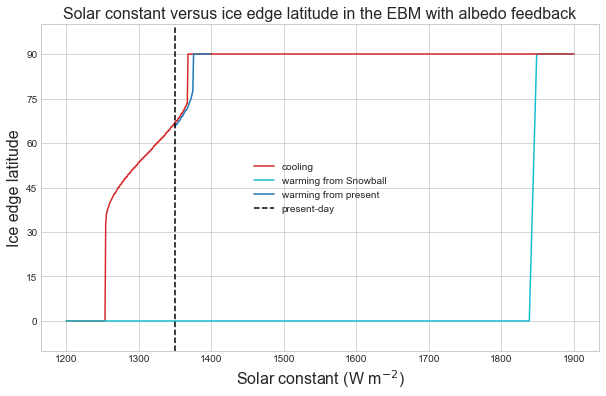

**Q:** Why do red and cyan trace different paths? Where does the warm branch tip? Where does the Snowball escape? What produces the gradual slope on the warm branch that has no analog in the 0D model?

**Q:** What is fundamentally the same between the 0D and 1D bifurcation diagrams? What does the 1D version add? Was the 1D model necessary to understand the Snowball bifurcation — and if so, for what question?

------------------------------------------------------------------------

------------------------------------------------------------------------


## Part 5: CO₂ Forcing

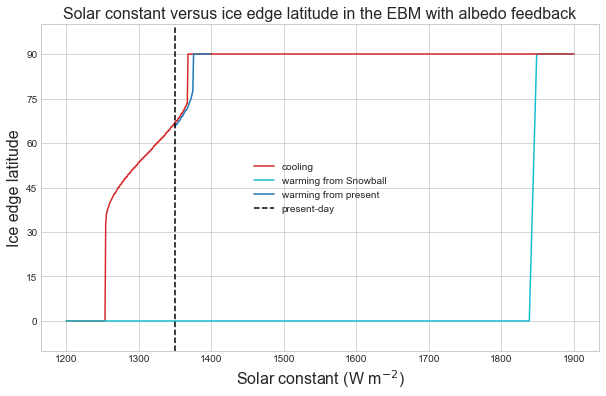

### CO₂ as the variable we influence

So far we have only changed $S_0$ — the solar constant. But the forcing we actually influence is CO₂. Unlike $S_0$, CO₂ does not change the incoming solar radiation. Instead it changes how efficiently the planet radiates to space: more CO₂ absorbs more outgoing longwave radiation, radiating in all directions, including down, thereby warming the surface.

In this model CO₂ enters through the `AplusBT_CO2` subprocess, which makes both $A$ and $B$ in the OLR parameterization functions of CO₂ concentration. Higher CO₂ lowers $A$, reducing OLR for a given temperature — the same effect as lowering $p_{rad}$ in the Lab 4 column model.

We will compare the warming pattern across a range of CO₂ values — from glacial (180 ppm) through preindustrial (280 ppm) to doubled (560 ppm) and quadrupled (1120 ppm) — and extract the latitude-dependent warming profile for each step.

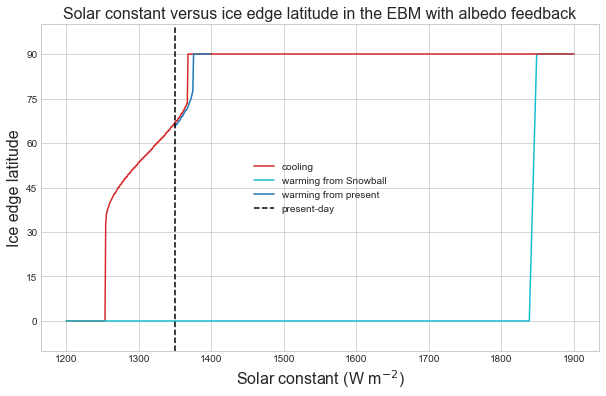

In [ ]:
#  Control: preindustrial CO2, present-day S0
model_pi = climlab.EBM_annual(num_lat=180, **param)
set_co2(model_pi, 280.)
model_pi.integrate_years(10, verbose=False)
print('Preindustrial ice edge:', model_pi.icelat)
print('Preindustrial Ts:      ', float(climlab.global_mean(model_pi.Ts)))

In [ ]:
#  Run at each CO2 level
co2_levels = {'glacial': 180., 'preindustrial': 280.,
              'present': 420., '2xCO2': 560., '4xCO2': 1120.}
colors     = {'glacial': 'tab:blue', 'preindustrial': 'steelblue',
              'present': 'gray',     '2xCO2': 'tab:orange', '4xCO2': 'tab:red'}

models_co2 = {}
for label, co2 in co2_levels.items():
    m = climlab.EBM_annual(num_lat=180, **param)
    set_co2(m, co2)
    m.integrate_years(10, verbose=False)
    models_co2[label] = m
    print(f'{label:>15} ({co2:.0f} ppm)  ice={np.max(m.icelat):.1f}°  '
          f'Ts={float(climlab.global_mean(m.Ts)):.1f}°C')

In [ ]:
#  Plot temperature profiles
fig, ax = plt.subplots(figsize=(9, 5))
for label, m in models_co2.items():
    ax.plot(m.lat, m.Ts, color=colors[label], lw=2, label=f'{label} ({co2_levels[label]:.0f} ppm)')
ax.axhline(param['Tf'], color='gray', ls=':', lw=1, label='$T_f$')
ax.set_xlabel('Latitude (°)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Temperature profiles across CO₂ levels')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
fig.tight_layout()

### Warming profiles and latitude-dependent sensitivity

Rather than looking at absolute temperatures, we want to see the warming that results from each CO₂ step relative to preindustrial. Compute $\Delta T(\phi)$ for each level, extract values at 20°N, 45°N, and 65°N, write the results to a CSV, and make a figure.

Compute warming profiles, extract latitude slices, write CSV.

In [ ]:
m_ref = models_co2['preindustrial']

warming_data = []
for label, m in models_co2.items():
    if label == 'preindustrial':
        continue
    dT_lat = m.Ts - m_ref.Ts
    dT_global = float(climlab.global_mean(dT_lat))

    row = {
        'co2_label': label,
        'co2_ppm':   co2_levels[label],
        'dT_global': dT_global,
        'dT_20N':    float(np.sqeeze(dT_lat[get_lat_idx(m, 20.)])),
        'dT_45N':    float(np.sqeeze(dT_lat[get_lat_idx(m, 45.)])),
        'dT_65N':    float(np.sqeeze(dT_lat[get_lat_idx(m, 65.)])),
    }
    warming_data.append(row)

df_warming = pd.DataFrame(warming_data)
print(df_warming.to_string(index=False))
df_warming.to_csv('lab08_warming_profiles.csv', index=False)
print('\nSaved to lab08_warming_profiles.csv')

Now read the CSV back in and make a plot. You will write the plotting code yourself — it should show $\Delta T$ at each latitude slice (and the global mean) as a function of CO₂ level.

Read the CSV and plot warming at each latitude as a function of CO₂. Your plot should: - Have CO₂ (ppm) on the x-axis - Show $\Delta T$ (°C) on the y-axis - Include a line for each latitude slice (20°N, 45°N, 65°N) and the global mean - Label axes and add a legend

In [ ]:
#  Read CSV and plot — write your plotting code here
df = pd.read_csv('lab08_warming_profiles.csv')
print('For reference, these are the columns of your dataframe:')
print(df.coluns)

# your code below

**Q:** Where is warming largest? Is it the same latitude as for the $S_0$ experiment? Where is the model most and least sensitive, and why? What is the ECS (global mean $\Delta T$ at 2×CO₂) and how does it compare to the Lab 5 result?

**Q:** Both CO₂ and $S_0$ forcing produce polar amplification through the ice-albedo feedback. Is the spatial pattern of the response the same for both? What would cause them to differ?

------------------------------------------------------------------------

------------------------------------------------------------------------